In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import sklearn.preprocessing
from sklearn.model_selection import train_test_split
plt.rcParams['axes.unicode_minus'] = False #用来正常显示负号

In [2]:
import scanpy as sc

In [3]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/lifesci/luosongwen/scantecc/ttf/arial.ttf')
mpl.rcParams["font.sans-serif"] = "Arial"
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.serif'] = ['Arial']

In [4]:
def readdata(data):

    final_si=pd.read_csv("/home/lifesci/luosongwen/workspace/scantecc/figure2d_code/ctyp.csv",index_col=0)

    data.columns=["SE-" + x[2:].split("-")[-1] if x[:2]=="SE" else x for x in data.columns]

    data_refine=data[data.columns.difference([x for x in data.columns if ("CF" in x) | ("R21063068" in x) ])]

    #data_refine.columns=[x.split("-")[-1].split("_")[0] for x in data_refine.columns]

    data_refine=data_refine.fillna(0)

    adata = sc.AnnData(data_refine[final_si.index].T)

    adata.obs['ctype'] = final_si.ctype
    
    return adata

In [5]:
d1=pd.read_table("/home/lifesci/luosongwen/workspace/scantecc/figure2d_code/all_mergeGeneName_coverage.count",index_col=0)
ad1=readdata(d1)

d2=pd.read_table("/home/lifesci/luosongwen/workspace/scantecc/figure2d_code/Final_gene_Score_cut.count",index_col=0)
ad2=readdata(d2)

In [6]:
mapping_dict = {
    "正常对照": "Healthy",  
    "肺癌": "Lung",
    "卵巢癌": "Ovarian",
    "胃癌": "Gastric",       
    "淋巴瘤": "Lymphoma"
}

In [7]:
if "ctype" in ad1.obs.columns:
    ad1.obs["ctype"] = ad1.obs["ctype"].map(mapping_dict).fillna(ad1.obs["ctype"])
    ad1.obs["ctype"] = ad1.obs["ctype"].astype("category")

if "ctype" in ad2.obs.columns:
    ad2.obs["ctype"] = ad2.obs["ctype"].map(mapping_dict).fillna(ad2.obs["ctype"])
    ad2.obs["ctype"] = ad2.obs["ctype"].astype("category")

In [8]:
use_ctype=['Healthy','Lung', 'Ovarian', 'Gastric', 'Lymphoma']

{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'scores'}>}

<Figure size 600x300 with 0 Axes>

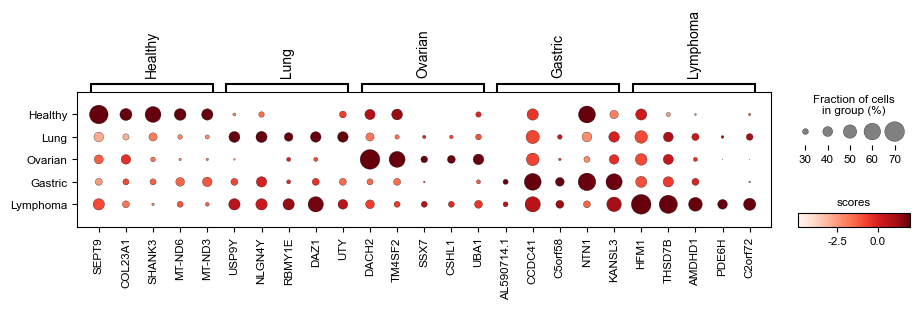

In [9]:
sc.pp.normalize_total(ad1)
# Logarithmize the data
sc.pp.log1p(ad1)

plt.figure(figsize = (6,3))
ad1.layers["scaled"]=sc.pp.scale(ad1,copy=True,zero_center=True).X

sc.tl.rank_genes_groups(ad1, 'ctype',method="t-test_overestim_var",groups=use_ctype
                        #layer="scaled",
                        #key_added='group_DE_results'
                       )


sc.pl.rank_genes_groups_dotplot(ad1, groupby='ctype', show=False,n_genes=5,layer="scaled",
                                categories_order=['Healthy','Lung', 'Ovarian', 'Gastric', 'Lymphoma'],
                                #swap_axes=True,
                                dendrogram=False,
                                values_to_plot="scores",
                    
                               min_logfoldchange=0.2,
                                expression_cutoff=0.4,
                               vmax=2,
                                dot_max=0.7,
                                dot_min=0.2,
                                
                               )
#plt.savefig("./gene_annotation/uncut2406-t-test.pdf",bbox_inches = 'tight')

{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'scores'}>}

<Figure size 600x300 with 0 Axes>

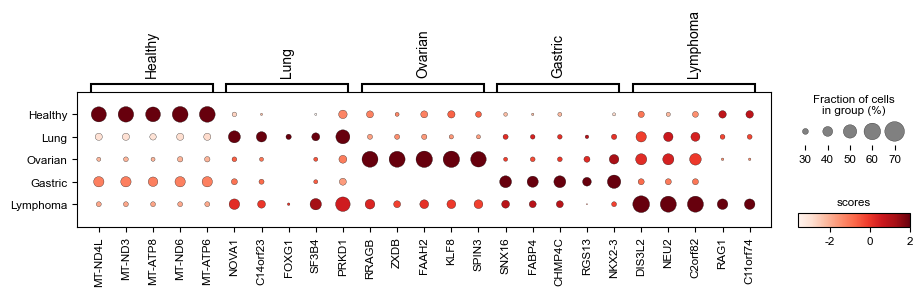

In [10]:
sc.pp.normalize_total(ad2)
# Logarithmize the data
sc.pp.log1p(ad2)


plt.figure(figsize = (6,3))
ad2.layers["scaled"]=sc.pp.scale(ad2,copy=True,zero_center=True).X

sc.tl.rank_genes_groups(ad2, 'ctype',method="t-test_overestim_var",groups=use_ctype
                        #layer="scaled",
                        #key_added='group_DE_results'
                       )



sc.pl.rank_genes_groups_dotplot(ad2, groupby='ctype', show=False,n_genes=5,layer="scaled",
                                categories_order=['Healthy','Lung', 'Ovarian', 'Gastric', 'Lymphoma'],
                                #swap_axes=True,
                                dendrogram=False,
                                values_to_plot="scores",
                    
                               min_logfoldchange=0.2,
                                expression_cutoff=0.4,
                               vmax=2,
                                dot_max=0.7,
                                dot_min=0.2,
                                
                               )
#plt.savefig("./gene_annotation/cut2406-t-test.pdf",bbox_inches = 'tight')